In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

In [7]:
width=4
gap = 2

In [31]:
cartesian_zte.shape

(12, 254, 254)

In [8]:
zte_radial_kspacedlt, zte_radial_coordsdlt = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacedlt, coords=zte_radial_coordsdlt)

## Zero Padding

In [10]:
n_coils = cartesian_zte.shape[0]
resize_x, resize_y = 512,512

dcf = np.sqrt(zte_radial_coordsdlt[..., 0]**2 + zte_radial_coordsdlt[..., 1]**2)
imagegrid = sp.nufft_adjoint(zte_radial_kspacedlt * dcf, zte_radial_coordsdlt, oshape=(12, 256,256))



image_grid_eng = sp.resize(imagegrid, [n_coils,resize_x, resize_y])

cartesian_kspace = sp.fft(imagegrid, axes=(-2, -1)) 

cartesian_kspace_enl = sp.fft(image_grid_eng, axes=(-2, -1))

In [11]:
cartesian_kspace_enl = asm.zero_padding(cartesian_zte, 512,512)

## Take an inner portion of the zero padded kspace
- choose `(L/2 - N):(L/2 + N)` where L is the kspace width and N is the inner region

In [12]:
N = 50

cx, cy = cartesian_kspace_enl.shape[1] // 2, cartesian_kspace_enl.shape[2] // 2

start, end = cx-N, cx+N


isolated_kspace = cartesian_kspace_enl[:, start:end, start:end]

##Important for putting data back in
isolation_mask = np.ones(cartesian_kspace_enl.shape[1:], dtype=int)
isolation_mask[start:end, start:end] = 0


#pl.ImagePlot(np.sum(np.abs(sp.ifft(cartesian_kspace_enl)**2)**0.5, axis=0))
#pl.ImagePlot(np.sum(np.abs(sp.ifft(isolated_kspace)**2)**0.5, axis=0))



In [14]:
N = 50


start, end = cx-N, cx+N

mask = np.ones((100, 100), dtype=bool)
mask[49:52, 49:52] = False
mask[48:53, 50] = False
mask[50, 48:53] = False

mask.shape[0]

100

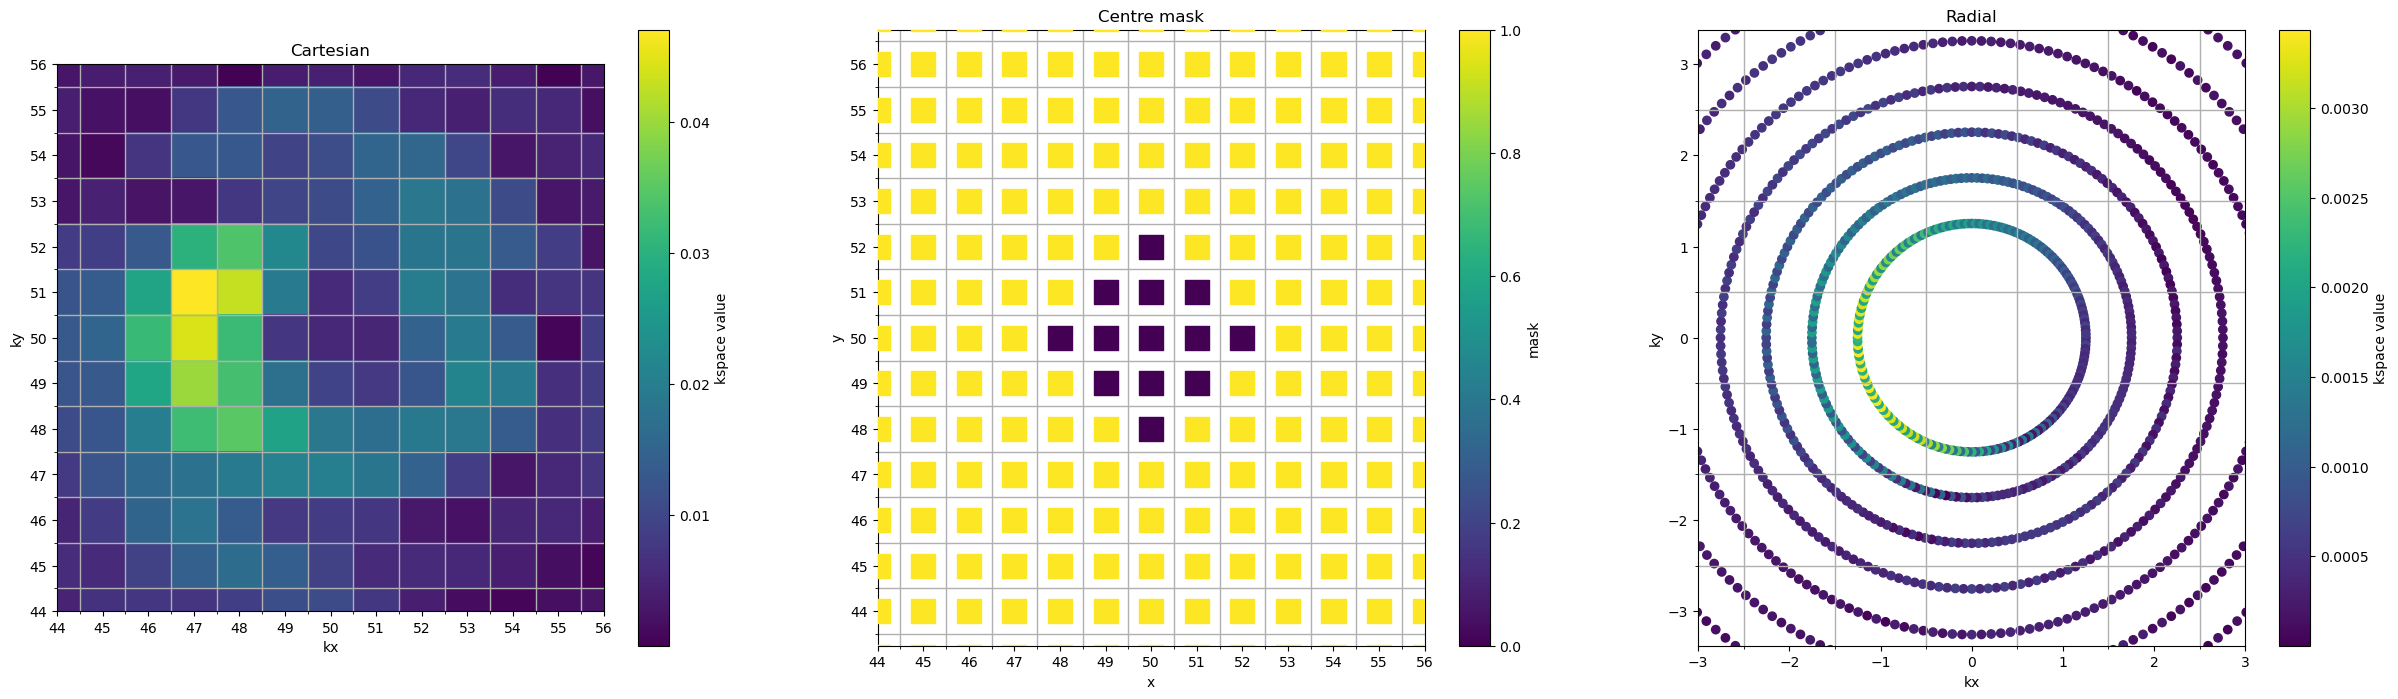

In [29]:
def plot_mask(isolated_kspace, mask, zte_radial_coords, zte_radial_kspace, sidelen):
    
    all_coords = zte_radial_coords.reshape(-1, 2)

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))
    
    im = ax[0].imshow(np.abs(isolated_kspace[0]), cmap='viridis', origin='lower')
    fig.colorbar(im, ax=ax[0], label='kspace value')
    ax[0].set_title('Cartesian')
    ax[0].set_xlabel('kx')
    ax[0].set_ylabel('ky')
    ax[0].set_xlim(100/2 - sidelen,100/2 + sidelen)
    ax[0].set_ylim(100/2 - sidelen,100/2 + sidelen)
    ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[0].grid(visible=True, which='minor', linewidth=1)
    ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


    yy, xx = np.mgrid[0:mask.shape[0], 0:mask.shape[0]]
    im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask.ravel().astype(int), cmap='viridis', s=300, marker='s', zorder=3)
    fig.colorbar(im1, ax=ax[1], label='mask')
    ax[1].set_title('Centre mask')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].axis('equal')
    ax[1].set_xlim(100/2 - sidelen,100/2 + sidelen)
    ax[1].set_ylim(100/2 - sidelen,100/2 + sidelen)
    ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[1].grid(visible=True, which='minor', linewidth=1)
    ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

    im2 = ax[2].scatter(all_coords[:, 0],all_coords[:, 1], c=np.abs(zte_radial_kspace[1]), cmap='viridis')
    fig.colorbar(im2, ax=ax[2], label='kspace value')
    ax[2].set_title('Radial')
    ax[2].set_xlabel('kx')
    ax[2].set_ylabel('ky')
    ax[2].axis('equal')
    ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[2].grid(visible=True, which='minor', linewidth=1)
    ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
    ax[2].set_xlim(0 - (sidelen//2), 0 + (sidelen//2))
    ax[2].set_ylim(0 - sidelen//2, 0 + (sidelen//2))

    plt.show()

plot_mask(isolated_kspace, mask=mask, zte_radial_coords=zte_radial_coordsdlt, zte_radial_kspace=zte_radial_kspacedlt, sidelen=6)

In [ ]:
def inner_portion(enlarged_kspace, inner_sidelen):
    """Take an inner square of kspace to speed up the hankel loop

        Args:
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)
            inner_sidelen: Side legnth of the inner square, divided by 2 to find from central point outward

        Returns:
            isolated_kspace: Inner kspace array
            isolation_mask: Mask of the inner region to use when 'jigsawing' the transformed array back in
            Start: xy index of the enlarged array that the inner region starts at
            End: xy index of the enlarged array that the inner region ends at
    """
    cx, cy = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end]
    
    return(isolated_kspace, isolation_mask, start, end)
inner_region, inner_mask, start, end = inner_portion(cartesian_kspace_enl, 100)

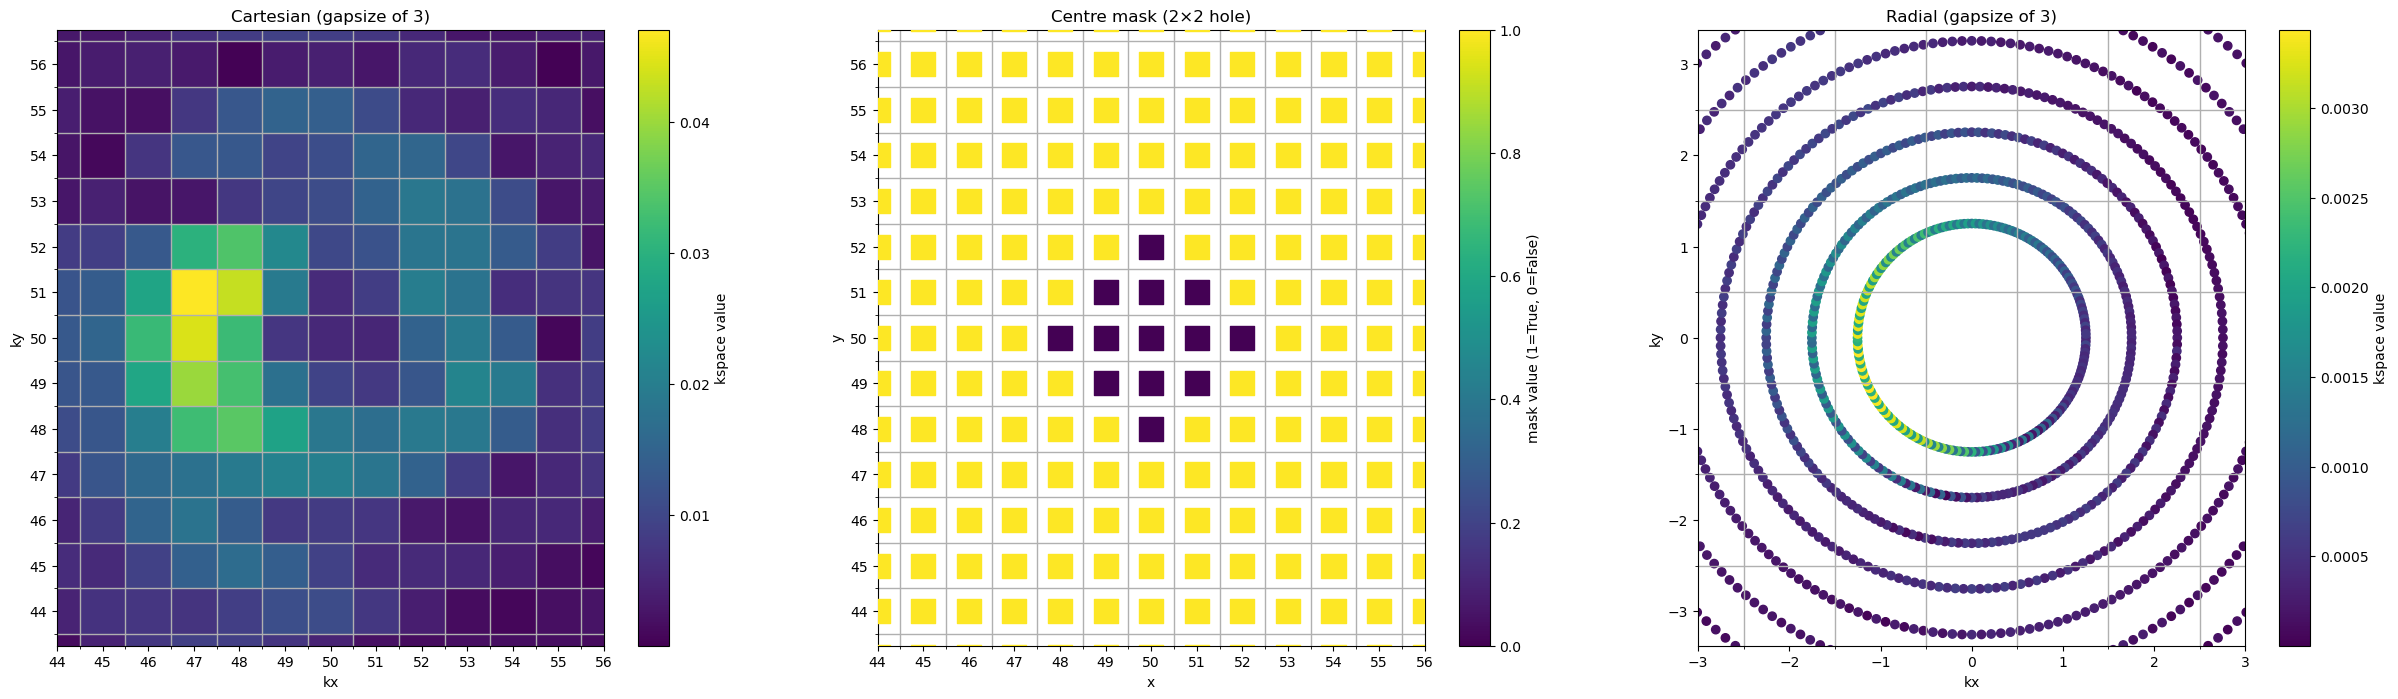

In [34]:
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))


im = ax[0].imshow(np.abs(isolated_kspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(100/2 - 6,100/2 + 6)
#ax[0].set_xlim(95,101)
ax[0].set_ylim(100/2 - 6,100/2 + 6)
ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].grid(visible=True, which='minor', linewidth=1)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


yy, xx = np.mgrid[0:100, 0:100]
im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask.ravel().astype(int), cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[1], label='mask value (1=True, 0=False)')
ax[1].set_title('Centre mask (2×2 hole)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].axis('equal')
ax[1].set_xlim(100/2 - 6,100/2 + 6)
ax[1].set_ylim(100/2 - 6,100/2 + 6)
ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))



im2 = ax[2].scatter(all_coords[:, 0],all_coords[:, 1], c=np.abs(zte_radial_kspacedlt[1]), cmap='viridis')
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial (gapsize of 3)')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(0 - 3, 0 + 3)
ax[2].set_ylim(0 - 3, 0 + 3)

plt.show()

## Properly zero out central points

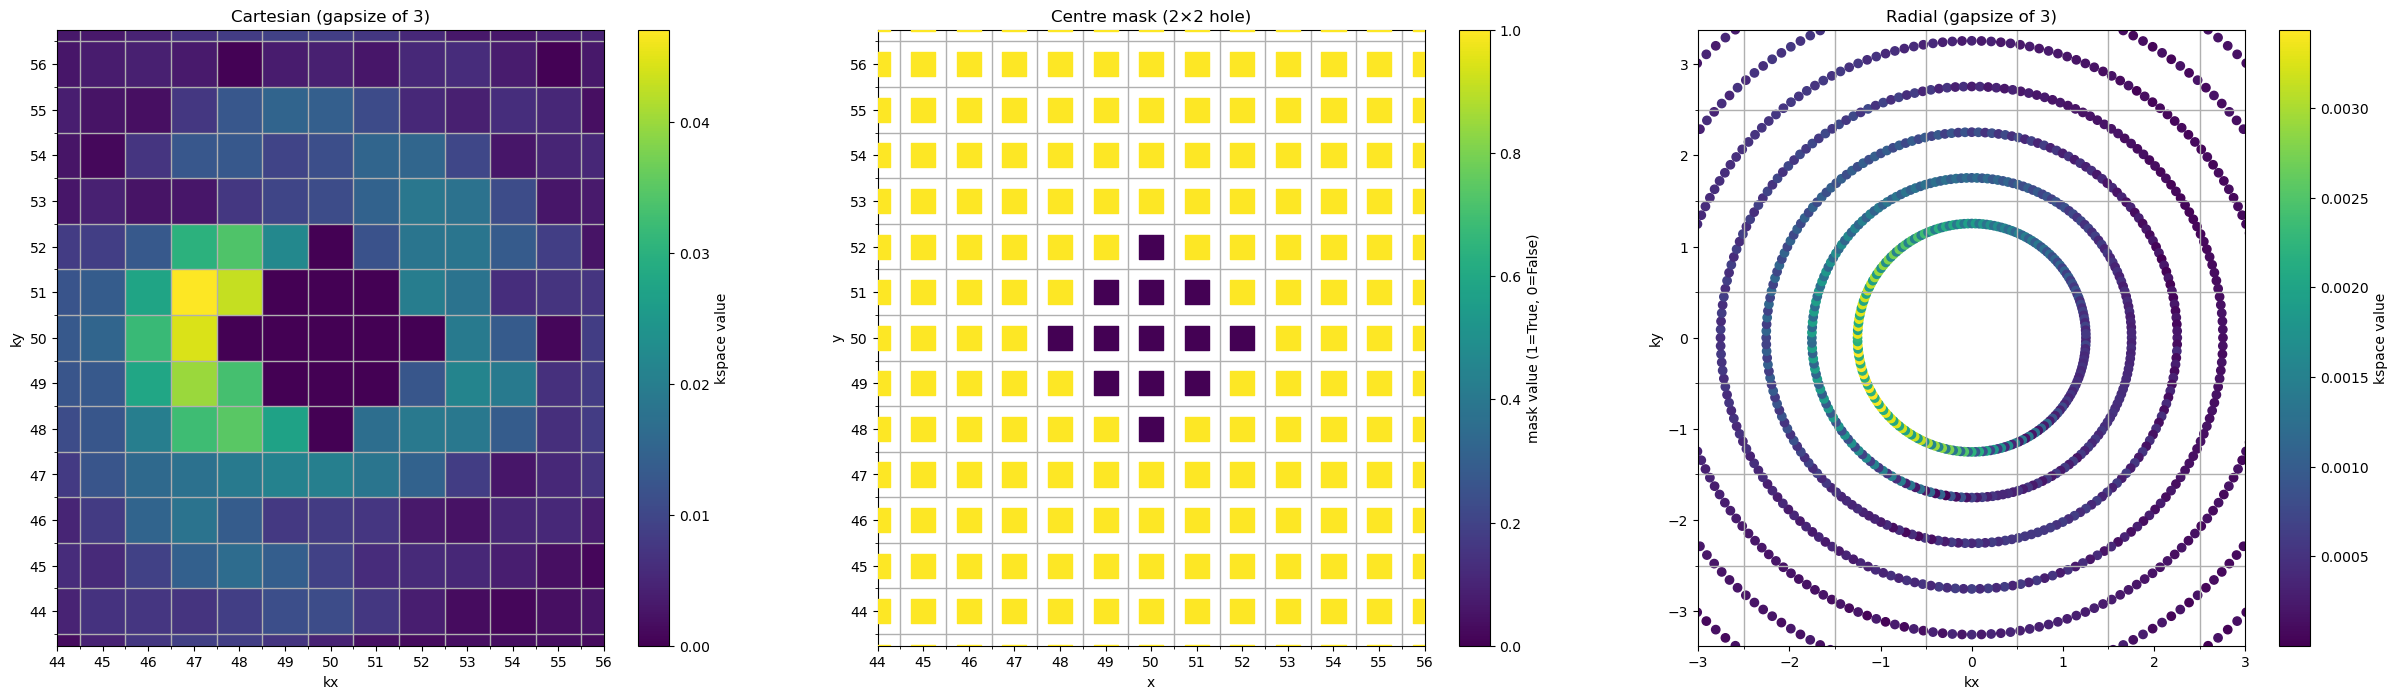

'pl.ImagePlot((np.sum(np.abs(sp.ifft(isolated_kspace_zeroed))**2, axis=0)**0.5))\npl.ImagePlot((np.sum(np.abs(sp.ifft(isolated_kspace))**2, axis=0)**0.5))'

In [9]:
isolated_kspace_zeroed = isolated_kspace.copy()
isolated_kspace_zeroed[:,~mask] = 0

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))


im = ax[0].imshow(np.abs(isolated_kspace_zeroed[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(100/2 - 6,100/2 + 6)
#ax[0].set_xlim(95,101)
ax[0].set_ylim(100/2 - 6,100/2 + 6)
ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0].grid(visible=True, which='minor', linewidth=1)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


yy, xx = np.mgrid[0:100, 0:100]
im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask.ravel().astype(int), cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im1, ax=ax[1], label='mask value (1=True, 0=False)')
ax[1].set_title('Centre mask (2×2 hole)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].axis('equal')
ax[1].set_xlim(100/2 - 6,100/2 + 6)
ax[1].set_ylim(100/2 - 6,100/2 + 6)
ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1].grid(visible=True, which='minor', linewidth=1)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))



im2 = ax[2].scatter(all_coords[:, 0],all_coords[:, 1], c=np.abs(zte_radial_kspacedlt[1]), cmap='viridis')
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial (gapsize of 3)')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(0 - 3, 0 + 3)
ax[2].set_ylim(0 - 3, 0 + 3)

plt.show()

'''pl.ImagePlot((np.sum(np.abs(sp.ifft(isolated_kspace_zeroed))**2, axis=0)**0.5))
pl.ImagePlot((np.sum(np.abs(sp.ifft(isolated_kspace))**2, axis=0)**0.5))'''

## Run loop and plot differences

In [ ]:
ksp_forhankel = isolated_kspace_zeroed.copy()

win = 5

n_iters = 20
iter_count = 0
#asm.im_recon_cart(kspace=cartesian_zte)
while iter_count < n_iters:
    
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=win)
    
    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.2)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=win)
    
    
    kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

    for coil in range(ksp_forhankel.shape[0]):
        kspace_cart_coils_consistent[coil, mask] = isolated_kspace_zeroed[coil, mask]

    ksp_forhankel = kspace_cart_coils_consistent.copy()
    iter_count += 1

In [13]:
def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = isolated_kspace_zeroed[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return(output_kspace)

In [14]:
post_loop_kspace = LORAKS_loop(20, 5, 0.5, isolated_kspace_zeroed, mask)

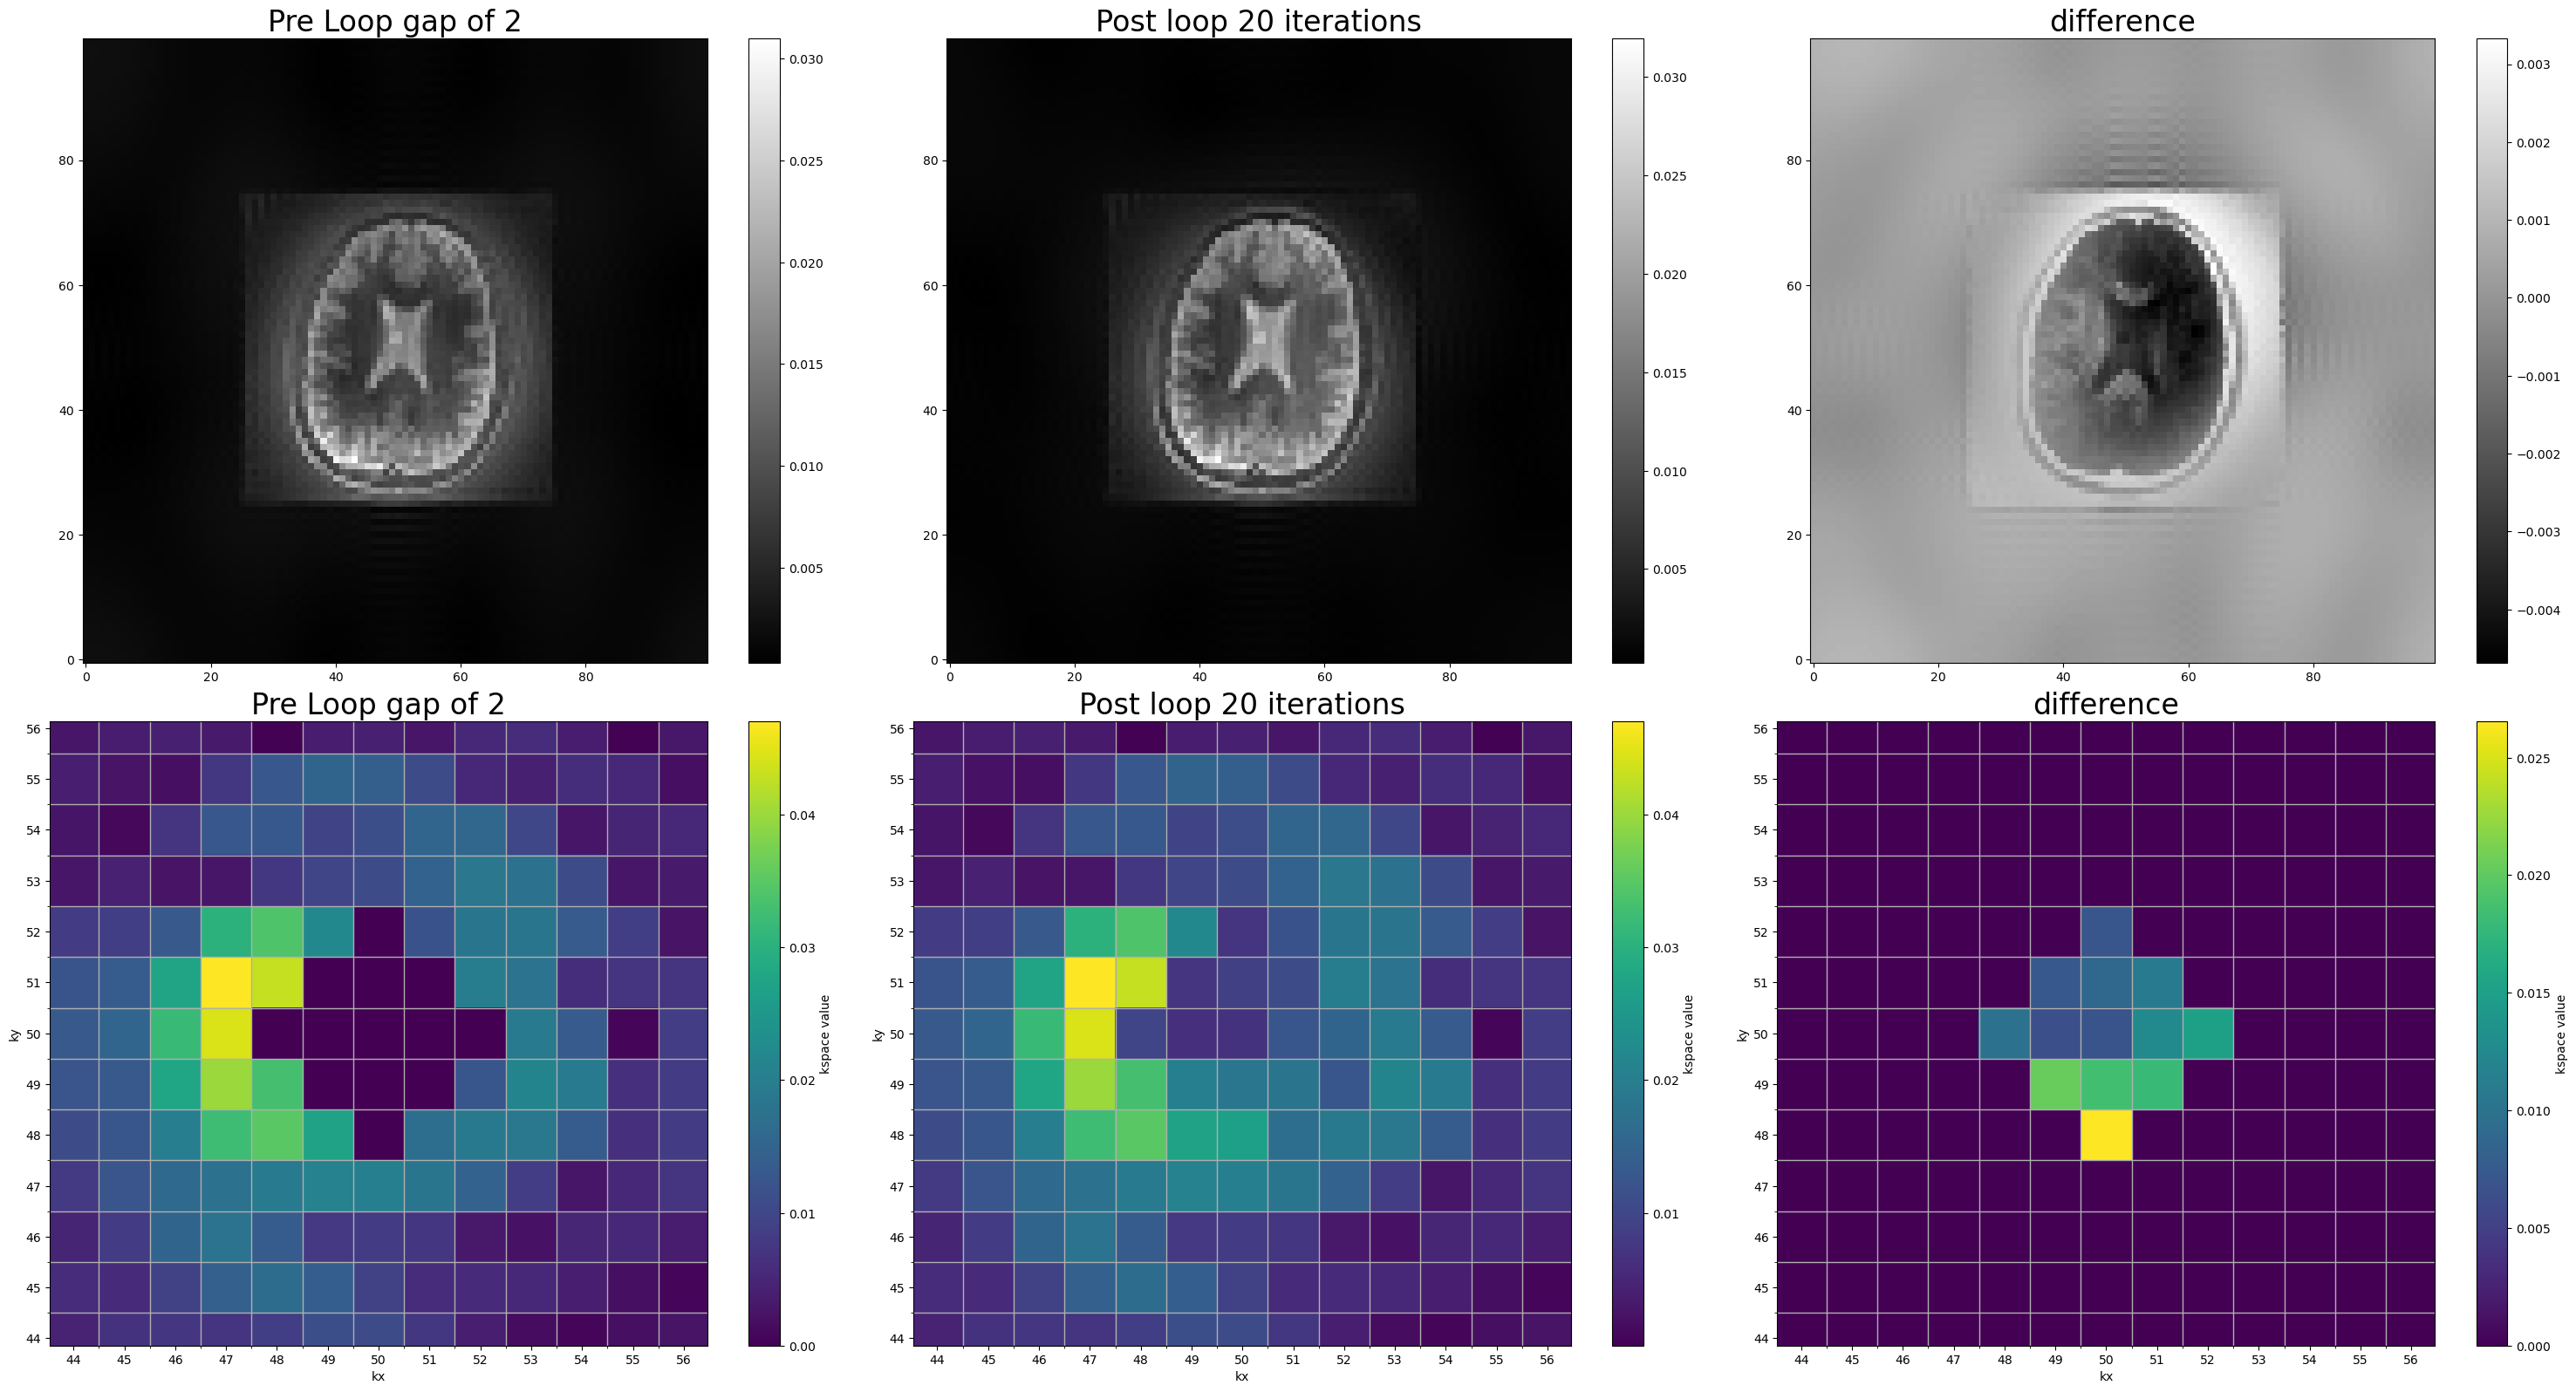

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(30, 16))

# Row 0: image-space magnitude
im1 = np.sum(np.abs(sp.ifft(isolated_kspace_zeroed))**2, axis=0)**0.5
p0 = ax[0, 0].imshow(im1, cmap='gray', origin='lower')
ax[0, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
fig.colorbar(p0, ax=ax[0, 0])

im2 = np.sum(np.abs(sp.ifft(post_loop_kspace))**2, axis=0)**0.5
p1 = ax[0, 1].imshow(im2, cmap='gray', origin='lower')
ax[0, 1].set_title(f'Post loop {20} iterations', fontsize=24)
fig.colorbar(p1, ax=ax[0, 1])

p2 = ax[0, 2].imshow(im1-im2, cmap='gray', origin='lower')
ax[0, 2].set_title('difference', fontsize=24)
fig.colorbar(p2, ax=ax[0, 2])

# Row 1: k-space
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

im = ax[1, 0].imshow(np.abs(isolated_kspace_zeroed[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 0], label='kspace value')
ax[1, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 0].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))

im1k = ax[1, 1].imshow(np.abs(post_loop_kspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k, ax=ax[1, 1], label='kspace value')
ax[1, 1].set_title(f'Post loop {20} iterations', fontsize=24)
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 1].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))

diff = isolated_kspace_zeroed - post_loop_kspace

im2k = ax[1, 2].imshow(np.abs(diff[0]), cmap='viridis', origin='lower')
fig.colorbar(im2k, ax=ax[1, 2], label='kspace value')
ax[1, 2].set_title('difference', fontsize=24)
ax[1, 2].set_xlabel('kx')
ax[1, 2].set_ylabel('ky')
ax[1, 2].axis('equal')
ax[1, 2].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 2].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].grid(visible=True, which='minor', linewidth=1)
ax[1, 2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

## Put data back into full grid

In [ ]:
def jigsaw(output_kspace, isolation_mask, start, end, enlarged_kspace):
    ### NOTE: There is a better way to do this without using start and end
    """Put the transormed region of kspace back into the zero padded region
        Args:
            output_kspace: Transformed SVD thresh kspace region
            isolation_mask: Mask of the inner region; typically output of asm.inner_portion
            Start: xy index of the enlarged array that the inner region starts at; typically output of asm.inner_portion 
            End: xy index of the enlarged array that the inner region ends at; typically output of asm.inner_portion
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)

        Returns:
            recombined: Zero padded kspace with transfomed inner region 'jigsawed' back in
    """
    processed_isolated_kspace = output_kspace.copy()
    recombined = enlarged_kspace * isolation_mask
    recombined[:, start:end, start:end] = processed_isolated_kspace
    return(recombined)

In [ ]:
processed_isolated_kspace = ksp_forhankel.copy()
recombined = cartesian_kspace_enl * isolation_mask  # zeroes the center
recombined[:, start:end, start:end] = processed_isolated_kspace

In [39]:
recombined = jigsaw(output_kspace=post_loop_kspace, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)

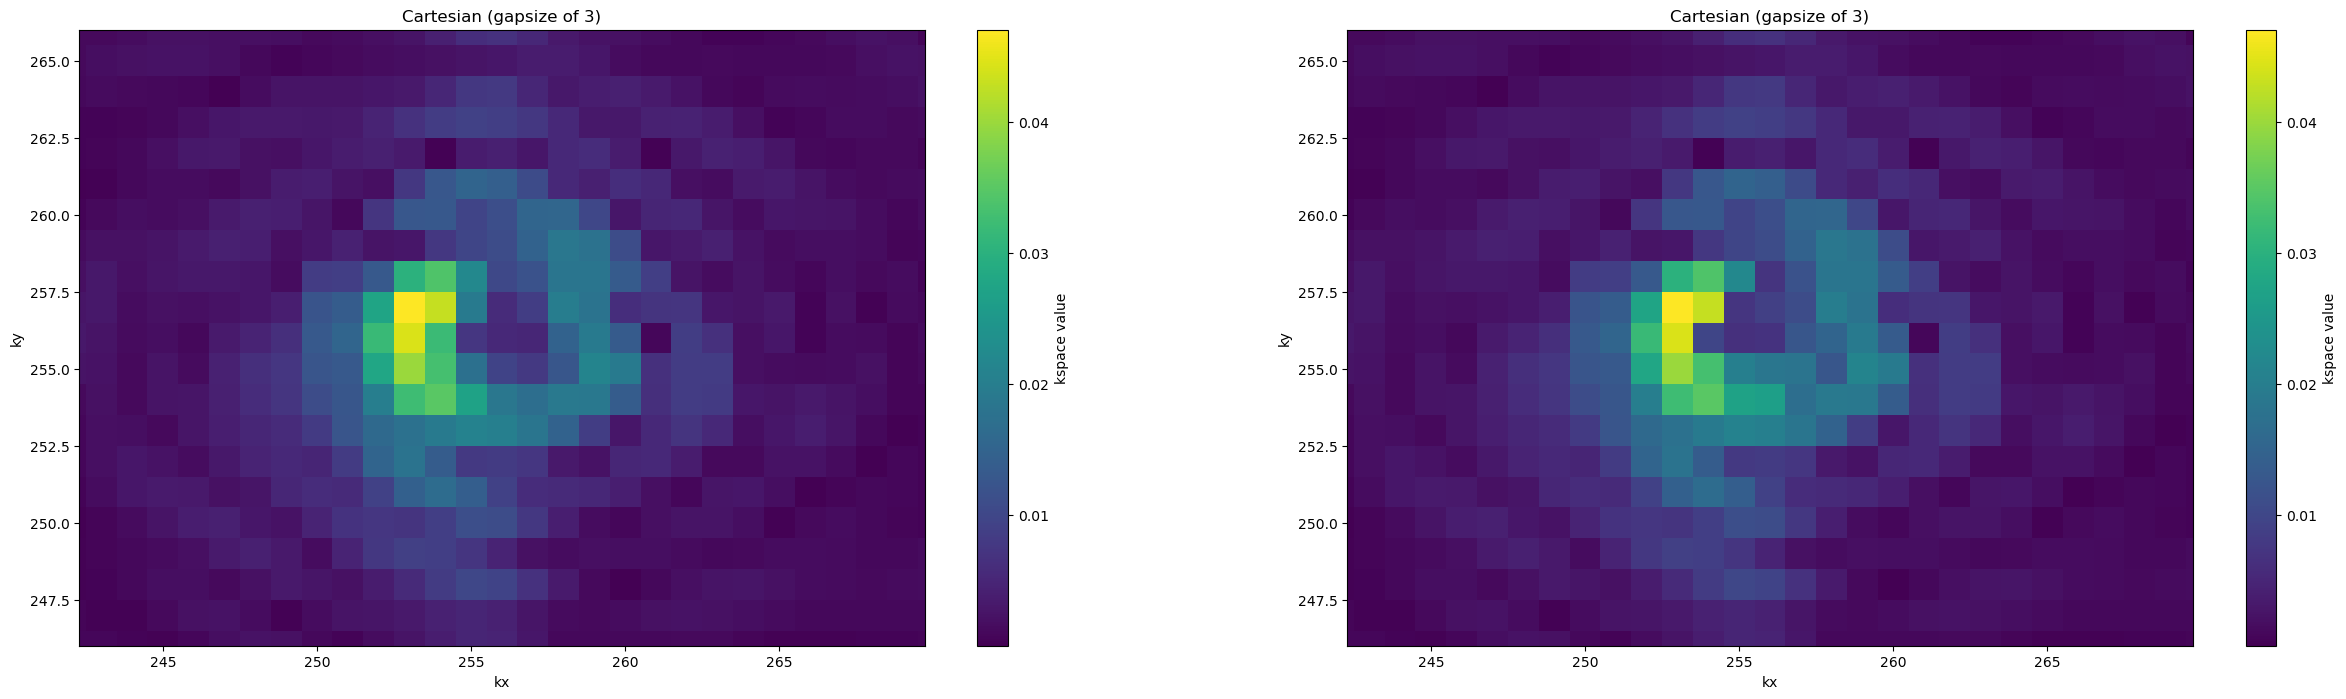

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(30, 8))


im = ax[0].imshow(np.abs(cartesian_kspace_enl[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(512/2 - 10,512/2 + 10)
ax[0].set_ylim(512/2 - 10,512/2 + 10)


im1 = ax[1].imshow(np.abs(recombined[0]), cmap='viridis', origin='lower')
fig.colorbar(im1, ax=ax[1], label='kspace value')

ax[1].set_title('Cartesian (gapsize of 3)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].set_xlim(512/2 - 10,512/2 + 10)
ax[1].set_ylim(512/2 - 10,512/2 + 10)



plt.show()

## De-zeropad

In [28]:
cartesian_kspace_rebuild = asm.zero_padding(recombined, 256,256)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

im_grid1 = sp.ifft(cartesian_kspace, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title('cartesian_kspace')

im_grid2 = sp.ifft(cartesian_kspace_rebuild, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title('cartesian_kspace_rebuild')

plt.tight_layout()
plt.show()

NameError: name 'recombined' is not defined